# Tugas 3: Mencoba Modul yang mengimplementasikan K-Means


Nama: Muhammad Fauzan Ashshidiq

NIM: 1237050051

Pembelajaran Mesin Kelas C

Dataset: Mall Customer Segmentation Data (https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

### Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### load data

In [9]:
# Baca file CSV
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### informasi tentang dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Eksplorasi Data Awal (EDA)

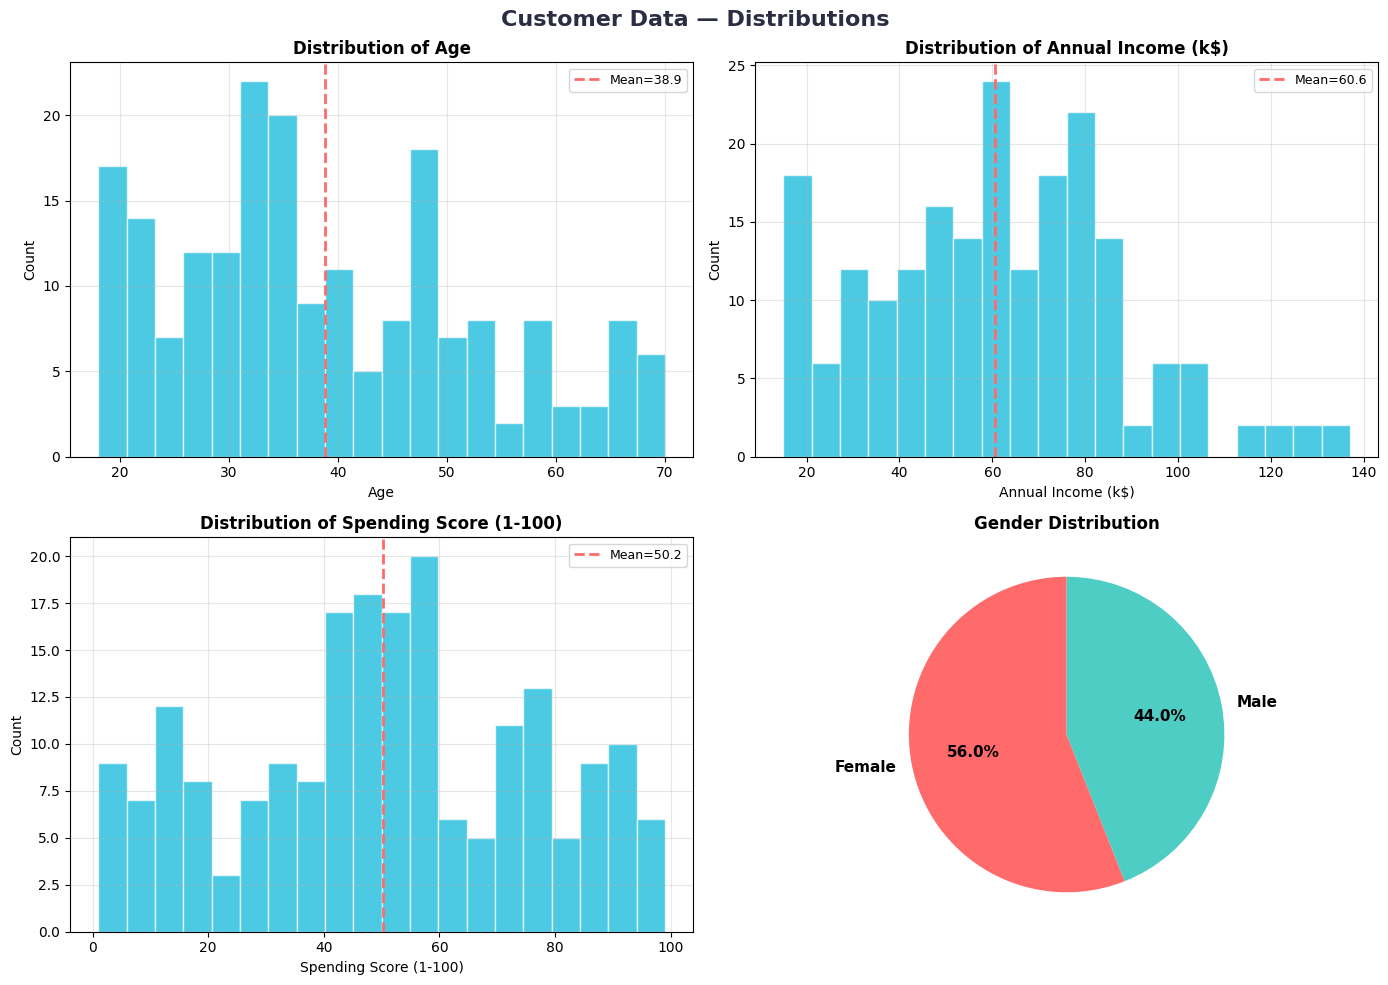

In [13]:
# Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for i, col in enumerate(num_cols):
    ax = axes[i//2][i%2]
    ax.hist(df[col], bins=20, color='#00B4D8', edgecolor='white', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.axvline(df[col].mean(), color='#FF6B6B', linestyle='--', linewidth=2, label=f'Mean={df[col].mean():.1f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1][1].pie(df['Gender'].value_counts(), labels=['Female', 'Male'],
                colors=['#FF6B6B', '#4ECDC4'], autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1][1].set_title('Gender Distribution', fontweight='bold', fontsize=12)

plt.suptitle('Customer Data — Distributions', fontsize=16, fontweight='bold', color='#2B2D42')
plt.tight_layout()
plt.show()

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


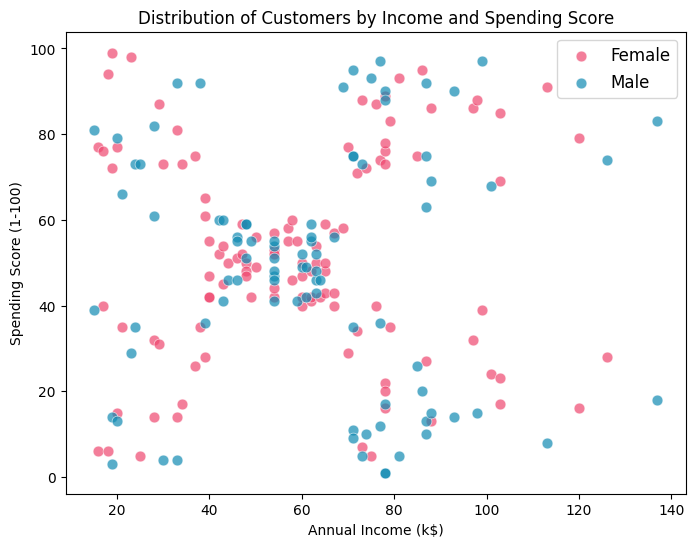

In [16]:
print(df.describe())

# Visualisasi distribusi Income vs Spending Score
colors = {'Male':'#118AB2', 'Female':'#EF476F'}
plt.figure(figsize=(8,6))
for gender, grp in df.groupby('Gender'):
    plt.scatter(grp['Annual Income (k$)'], grp['Spending Score (1-100)'],
                c=colors[gender], label=gender, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Distribution of Customers by Income and Spending Score')
plt.legend(fontsize=12)
plt.show()

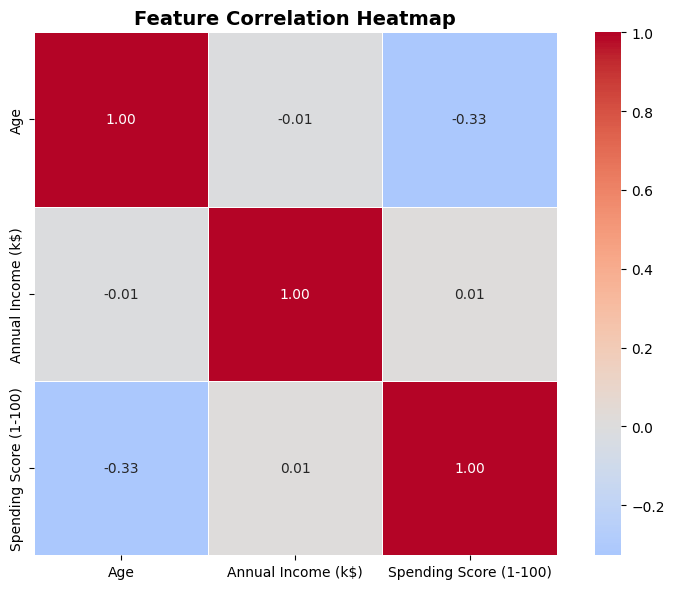

In [17]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Seleksi Fitur

In [18]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

### Scalling

In [19]:
# Standarisasi dengan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cek hasil standarisasi (mean=0, std=1)
print(f"Mean: {X_scaled.mean():.2f}")
print(f"Std: {X_scaled.std():.2f}")

Mean: -0.00
Std: 1.00


### Menentukan Jumlah Cluster Optimal (k)

#### Elbow Method

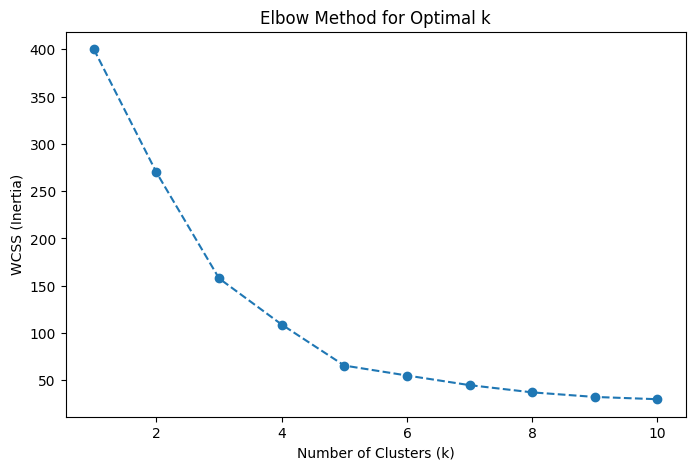

In [25]:
wcss = []  # Within-Cluster Sum of Square

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# Plot Elbow
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

#### Silhouette Score

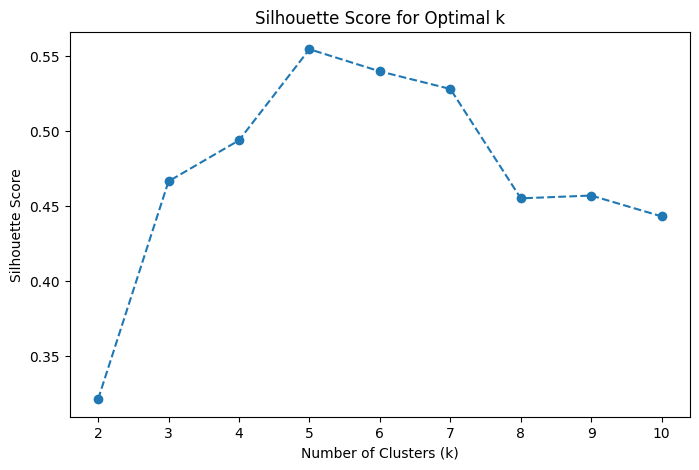

In [26]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sil_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

### Membuat Model Clustering

In [30]:
# Tentukan k optimal
optimal_k = 5

# Latih model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Tambahkan hasil cluster ke dataframe
df['Cluster'] = clusters

# Lihat hasil
df[['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


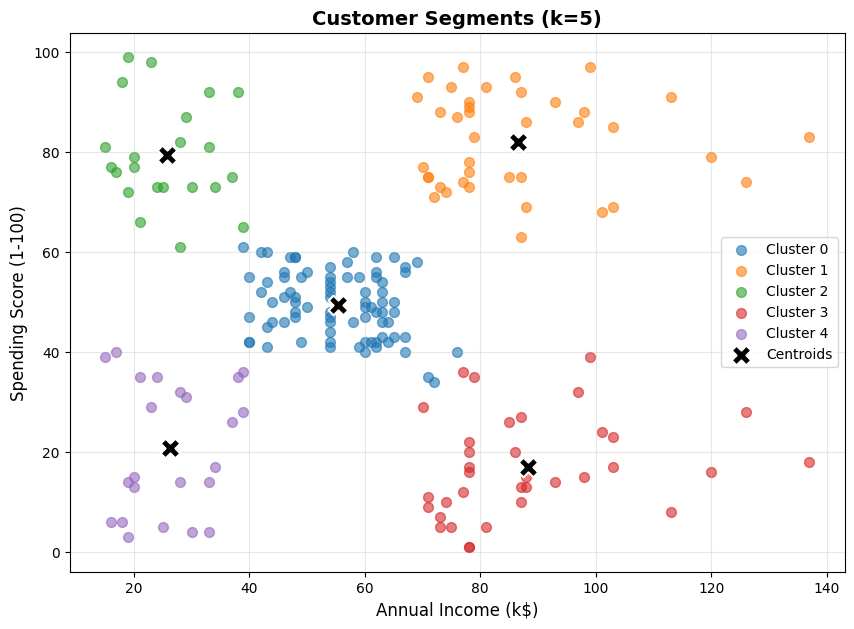

In [36]:
# Visualisasi cluster
plt.figure(figsize=(10,7))

X_original = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Plot setiap cluster dengan warna berbeda (pakai skala asli)
for cluster in range(optimal_k):
    cluster_data = X_original[clusters == cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                label=f'Cluster {cluster}', alpha=0.6, s=50)

# Plot centroids (dalam skala asli)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X',
            label='Centroids', zorder=10, edgecolors='white', linewidths=1.5)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'Customer Segments (k={optimal_k})', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Analisis segmentasi
segment_analysis = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Jumlah Pelanggan'})

print(segment_analysis.round(2))

# Juga lihat distribusi gender per cluster
print(df.groupby('Cluster')['Gender'].value_counts())

           Age  Annual Income (k$)  Spending Score (1-100)  Jumlah Pelanggan
Cluster                                                                     
0        42.72               55.30                   49.52                81
1        32.69               86.54                   82.13                39
2        25.27               25.73                   79.36                22
3        41.11               88.20                   17.11                35
4        45.22               26.30                   20.91                23
Cluster  Gender
0        Female    48
         Male      33
1        Female    21
         Male      18
2        Female    13
         Male       9
3        Male      19
         Female    16
4        Female    14
         Male       9
Name: count, dtype: int64


### Interpretasi Detail Per Cluster

#### Tabel 1: Karakteristik Utama Setiap Cluster

| Cluster | Usia (tahun) | Pendapatan (k$) | Skor Belanja | Jumlah Pelanggan | Nama Segmentasi |
|:---:|:---:|:---:|:---:|:---:|:---|
| **0** | 42.7 | 55.3 | 49.5 | 81 | **Pelanggan Menengah Stabil** |
| **1** | 32.7 | 86.5 | 82.1 | 39 | **Pelanggan Berpenghasilan Tinggi** |
| **2** | 25.3 | 25.7 | 79.4 | 22 | **Pelanggan Hemat Berbelanja Tinggi** |
| **3** | 41.1 | 88.2 | 17.1 | 35 | **Pelanggan Kaya Namun Hemat** |
| **4** | 45.2 | 26.3 | 20.9 | 23 | **Pelanggan Berpenghasilan Rendah** |

**Keterangan:**
- **Pendapatan** dalam satuan ribuan dollar (k$)
- **Skor Belanja** rentang 1-100 (semakin tinggi semakin sering/banyak belanja)

#### Tabel 2: Komposisi Gender per Cluster

| Cluster | Segmentasi | Perempuan | Laki-laki | Dominasi |
|:---:|:---|:---:|:---:|:---|
| **0** | Pelanggan Menengah Stabil | 48 | 33 |  Perempuan (59%) |
| **1** | Pelanggan Berpenghasilan Tinggi | 21 | 18 |  Perempuan (54%) |
| **2** | Pelanggan Hemat Berbelanja Tinggi | 13 | 9 |  Perempuan (59%) |
| **3** | Pelanggan Kaya Namun Hemat | 16 | 19 |  Laki-laki (54%) |
| **4** | Pelanggan Berpenghasilan Rendah | 14 | 9 |  Perempuan (61%) |

**Total Seluruh Pelanggan:** 200 orang
- **Perempuan:** 112 orang (56%)
- **Laki-laki:** 88 orang (44%)